# Lec8 — Diffusion Models
### Forward noising + learned reverse denoising

**Prerequisites:** probability basics (Gaussians), Lec2–Lec5 materials

| Part | Topic | Key idea |
|---|---|---|
| 1 | Distribution modeling | image generation = learn a data distribution $p_{\text{data}}(x)$ |
| 2 | Forward process | progressively add Gaussian noise with a known Markov chain |
| 3 | Oracle reverse | if the injected noise is known, reconstructing backward works exactly |
| 4 | Distribution transition | watch data distributions become Gaussian noise |
| 5 | Naive learned reverse | directly predicting $x_{t-1}$ is natural but fragile |
| 6 | Direct clean-image prediction | learn $x_t \rightarrow x_0$ as a denoising model |
| 7 | DDPM noise prediction | predict $\varepsilon$ instead, then reconstruct/sampling follows |
| 8 | Tiny MNIST model | train a compact U-Net denoiser and inspect diagnostics |


---
## Learning ladder

This lecture is designed as a sequence of increasingly practical reverse-process ideas.

| Step | Question | What we learn |
|---|---|---|
| Forward process | How do we turn images into noise? | Gaussian kernels give a known noising chain $q(x_t\mid x_{t-1})$. |
| Oracle reverse | Can backward reconstruction work at all? | Yes, if the hidden injected noise is known. |
| Direct $x_{t-1}$ prediction | Can a model learn the previous state? | It is natural, but the target is stochastic and ambiguous. |
| Direct $x_0$ prediction | Can a model denoise directly to the clean image? | Yes, but difficulty varies strongly with timestep. |
| Noise prediction | Can we predict the hidden corruption variable? | This gives a standardized target and the DDPM reverse formula. |

The main conceptual move is: **do not ask the model to guess an arbitrary previous noisy state; ask it to infer the noise component inside the current noisy image.**


Each learned reverse method is evaluated in two ways: **Check A** asks whether the local supervised target works on data-created noisy images, and **Check B** asks whether repeated reverse updates can generate from fresh Gaussian noise.


---
## (1) Distribution modeling for image generation

In generative modeling, we want to learn a model distribution $p_\theta(x)$ that matches the (unknown) data distribution $p_{\text{data}}(x)$.

- If we can sample $x \sim p_\theta(x)$, we can generate images.
- The challenge: images are high-dimensional (e.g. $x \in \mathbb{R}^{784}$ for MNIST, or much larger for real images).

**Diffusion model idea (high level):**

Instead of generating $x$ in one shot, create a **sequence of intermediate distributions**

$$q_0(x) \to q_1(x) \to \cdots \to q_T(x)$$

such that:

- $q_0(x)$ is the data distribution (clean images)
- $q_T(x)$ is a simple distribution (e.g. standard Gaussian noise)

Then we learn a reverse process that goes from noise back to data.

You can think of each time step $t$ as defining a *noise level* and therefore an **intermediate distribution** $q_t(x_t)$.

By the end of this lecture, every formula should answer one practical question: what information do we need in order to move from noisy images back toward clean images?


---
## (2) Forward diffusion as a Gaussian-kernel transition

We define a **forward noising process** (a Markov chain):

$$q(x_t \mid x_{t-1}) = \mathcal{N}\big(\sqrt{1-\beta_t}\,x_{t-1},\; \beta_t I\big), \qquad t=1,\dots,T$$

Equivalently, we can sample it as:

$$x_t = \sqrt{1-\beta_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,I).$$

Why this is a **Gaussian kernel** transition:

- Each step adds Gaussian noise, which is a **convolution with a Gaussian kernel** in the space of images.
- Repeating this transition pushes any complicated distribution toward a Gaussian (for large enough $T$).

A useful closed-form relationship (we’ll verify in code):

$$q(x_t \mid x_0) = \mathcal{N}\big(\sqrt{\bar\alpha_t}\,x_0,\; (1-\bar\alpha_t) I\big), \quad \bar\alpha_t = \prod_{s=1}^t (1-\beta_s).$$


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print('device:', device)


In [ ]:
# Load MNIST (same approach as earlier lectures)
print("Loading MNIST... (cached after first run)")
mnist   = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_mnist = mnist.data.astype(np.float32) / 255.0
X_mnist = X_mnist * 2.0 - 1.0   # DDPM convention: train images in [-1, 1]
y_mnist = mnist.target.astype(int)

X_tr, X_te = X_mnist[:60000], X_mnist[60000:]
y_tr, y_te = y_mnist[:60000], y_mnist[60000:]

def make_dl(X, y, batch_size, shuffle):
    Xt = torch.tensor(X).view(-1, 1, 28, 28)
    yt = torch.tensor(y)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_dl = make_dl(X_tr, y_tr, 256, True)
test_dl  = make_dl(X_te, y_te, 512, False)

imgs_test, labels_test = next(iter(test_dl))
print('batch:', imgs_test.shape)


In [ ]:
# Forward process parameters

def linear_beta_schedule(T, beta_start=1e-4, beta_end=8e-2):
    # A slightly stronger end noise is important for a short teaching chain.
    # With T=200 and beta_end=0.02, alpha_bar_T is still ~0.13, so x_T is not close to pure noise.
    return torch.linspace(beta_start, beta_end, T)

T = 200
betas = linear_beta_schedule(T).to(device)         # betas[0] is beta_1
alphas = 1.0 - betas                              # alphas[0] is alpha_1
alpha_bar = torch.cumprod(alphas, dim=0)          # cumulative product of alphas

# For teaching clarity, define alpha_bar0[0] = 1 so that x_0 is exactly the clean image.
# alpha_bar0[t] stores the cumulative product up to step t (t=0..T).
alpha_bar0 = torch.cat([torch.ones(1, device=device), alpha_bar], dim=0)

print('T:', T)
print('beta range:', float(betas.min()), '->', float(betas.max()))
print('alpha_bar0[0]:', float(alpha_bar0[0]), 'alpha_bar0[T]:', float(alpha_bar0[T]))

# Images are trained in [-1, 1], but displayed in [0, 1].
def to_display(x):
    return ((x.clamp(-1, 1) + 1.0) / 2.0).detach()

# Convenience: gather per-t coefficients for a batch of timesteps.
def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.view(-1, *([1] * (len(x_shape) - 1)))

# Closed-form sampling from q(x_t | x_0).
def q_sample(x0, t, noise=None):
    # Sample x_t given x_0 at discrete time index t (0..T).
    if noise is None:
        noise = torch.randn_like(x0)
    a_bar = extract(alpha_bar0, t, x0.shape)
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise

def predict_x0_from_eps(x_t, t, eps):
    # Exact inversion of q_sample when eps is the true forward noise.
    a_bar = extract(alpha_bar0, t, x_t.shape)
    return (x_t - torch.sqrt(1.0 - a_bar) * eps) / torch.sqrt(a_bar).clamp(min=1e-8)

# Sanity check: if eps is known exactly, reconstruction of x0 should be numerically exact.
with torch.no_grad():
    x0_check = imgs_test[:8].to(device)
    t_check = torch.randint(1, T + 1, (x0_check.shape[0],), device=device, dtype=torch.long)
    eps_check = torch.randn_like(x0_check)
    x_t_check = q_sample(x0_check, t_check, eps_check)
    x0_recon_check = predict_x0_from_eps(x_t_check, t_check, eps_check)
    print('closed-form x0 reconstruction MSE with true eps:', F.mse_loss(x0_recon_check, x0_check).item() if 'F' in globals() else float(((x0_recon_check - x0_check) ** 2).mean()))


In [ ]:
# Visualise: forward noising of a single MNIST image across timesteps
x0 = imgs_test[0:1].to(device)

steps = [0, 1, 2, 5, 10, 20, 50, 100, 150, T]

def show_row(images, titles, figsize=(15, 2.2)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    for ax, img, ttl in zip(axes, images, titles):
        ax.imshow(to_display(img)[0,0], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        ax.set_title(ttl, fontsize=9)
    plt.tight_layout(); plt.show()

imgs = []
for t in steps:
    xt = q_sample(x0, torch.tensor([t], device=device))
    imgs.append(xt.detach().cpu())

show_row(imgs, [f"t={t}" for t in steps])
print('Forward process: x_t gradually becomes pure noise as t increases.')


In [ ]:
# Visualise many images across timesteps (grid)
# Rows: different initial images x0
# Cols: the same image diffused to different time steps t
# Here we simulate the *Markov* forward chain so each step adds fresh Gaussian noise.

n_rows = 8
steps = [0, 1, 2, 5, 10, 20, 50, 100, 150, T]
max_t = max(steps)

x = imgs_test[:n_rows].to(device)
labels_batch = labels_test[:n_rows].cpu().numpy()

snap = {0: x.detach().cpu()}
for t in range(1, max_t + 1):
    eps = torch.randn_like(x)
    beta = betas[t - 1]
    x = torch.sqrt(1.0 - beta) * x + torch.sqrt(beta) * eps
    if t in steps:
        snap[t] = x.detach().cpu()

fig, axes = plt.subplots(n_rows, len(steps), figsize=(1.45*len(steps), 1.45*n_rows))

for r in range(n_rows):
    for c, t in enumerate(steps):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        x_t = snap[t][r:r+1]
        ax.imshow(to_display(x_t)[0,0], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if r == 0:
            ax.set_title(f"t={t}", fontsize=9)
    axes[r, 0].set_ylabel(f"y={labels_batch[r]}", rotation=0, labelpad=18, fontsize=9, va='center')

plt.suptitle(
    f"Forward diffusion on multiple images (Markov chain)\n(each row = one x0 image; each column = a noise level up to t={T})",
    fontsize=11
)
plt.tight_layout(); plt.show()


---
## (3) Oracle reverse: reconstructing backward works if the noise is known

Before learning anything, let us separate two facts:

1. The forward process itself is **not mysterious**. It is a known Gaussian transition.
2. Reversing it is easy **if we know the exact noise that was injected**.

For the one-step Markov transition,

$$x_t = \sqrt{\alpha_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon_t,$$

we can algebraically invert it if $\varepsilon_t$ is known:

$$x_{t-1} = \frac{x_t - \sqrt{\beta_t}\,\varepsilon_t}{\sqrt{\alpha_t}}.$$

Likewise, for the closed-form corruption,

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,$$

we can recover $x_0$ exactly if the aggregate noise $\varepsilon$ is known.

The problem in generation is that we start only from noise $x_T \sim \mathcal{N}(0,I)$; we do **not** know the noise variables that created it from a real image. Diffusion learning is therefore a supervised way to infer the missing noise/reverse direction.


In [ ]:
# Oracle reverse demo: if we save the injected noise, backward reconstruction is exact.
@torch.no_grad()
def forward_markov_save_noise(x0, T):
    x = x0.clone()
    noises = []
    states = [x.detach().cpu()]
    for tt in range(1, T + 1):
        eps_t = torch.randn_like(x)
        beta_t = betas[tt - 1]
        alpha_t = alphas[tt - 1]
        x = torch.sqrt(alpha_t) * x + torch.sqrt(beta_t) * eps_t
        noises.append(eps_t.detach().cpu())
        if tt in {1, 10, 50, 100, 150, T}:
            states.append(x.detach().cpu())
    return x.detach().cpu(), noises, states

@torch.no_grad()
def reverse_markov_with_saved_noise(x_T, noises):
    x = x_T.to(device)
    for tt in reversed(range(1, T + 1)):
        eps_t = noises[tt - 1].to(device)
        beta_t = betas[tt - 1]
        alpha_t = alphas[tt - 1]
        x = (x - torch.sqrt(beta_t) * eps_t) / torch.sqrt(alpha_t)
    return x.detach().cpu()

x0_oracle = imgs_test[:8].to(device)
xT_oracle, saved_noises, _ = forward_markov_save_noise(x0_oracle, T)
x0_back = reverse_markov_with_saved_noise(xT_oracle, saved_noises)
markov_mse = F.mse_loss(x0_back.to(device), x0_oracle).item()
print('Exact Markov reverse MSE when every eps_t is saved:', markov_mse)

# Closed-form oracle: recover x0 from x_t if the aggregate epsilon is known.
t_oracle = torch.full((x0_oracle.shape[0],), min(150, T), device=device, dtype=torch.long)
eps_oracle = torch.randn_like(x0_oracle)
xt_oracle = q_sample(x0_oracle, t_oracle, eps_oracle)
x0_closed = predict_x0_from_eps(xt_oracle, t_oracle, eps_oracle)
closed_mse = F.mse_loss(x0_closed, x0_oracle).item()
print('Exact closed-form x0 reconstruction MSE with true aggregate eps:', closed_mse)

# Visual comparison: clean image, very noisy final state, exact backward reconstruction.
fig, axes = plt.subplots(8, 3, figsize=(6.2, 12))
for i in range(8):
    axes[i, 0].imshow(to_display(x0_oracle[i:i+1].cpu())[0, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 1].imshow(to_display(xT_oracle[i:i+1])[0, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 2].imshow(to_display(x0_back[i:i+1])[0, 0], cmap='gray', vmin=0, vmax=1)
    for j in range(3):
        axes[i, j].axis('off')
axes[0, 0].set_title('clean x0')
axes[0, 1].set_title('x_T')
axes[0, 2].set_title('exact reverse')
plt.suptitle('Oracle reverse works: the missing ingredient is the injected noise')
plt.tight_layout(); plt.show()


---
### Checkpoint after oracle reverse

The previous cell should give almost-zero reconstruction error. This proves the forward chain did **not** destroy information if we secretly keep every noise draw.

But generation does not give us those hidden noise draws. At test time we only have a fresh sample from $x_T \sim \mathcal{N}(0,I)$. Therefore the learning problem is: **infer enough about the missing reverse direction from data.**


---
## (4) Distribution transition (MNIST + toy 2D)

The forward process does not only corrupt one image — it transforms the **entire data distribution**.

A good way to see this is: for a fixed time step $t$, draw many samples from $q_t(x_t)$.

- At $t=0$, samples look like clean digits (data distribution).
- As $t$ increases, samples become progressively noisier.
- For large $t$, samples look like nearly pure Gaussian noise.

First we visualise this on MNIST by showing a *block of many samples* at each time step.
Then we repeat the same idea on a simple 2D mixture-of-Gaussians dataset.


In [ ]:
# Distribution snapshots on MNIST: samples from q_t(x_t)
# Each panel is a different time step t, showing many samples (a mini-grid) from that intermediate distribution.
# We simulate the Markov forward chain on a batch of many different x0 images.

steps = [0, 10, 50, 100, T]
max_t = max(steps)

n_rows, n_cols = 6, 6
n = n_rows * n_cols

# Pick n different clean images x0
perm = torch.randperm(imgs_test.shape[0])[:n]
x = imgs_test[perm].to(device)

snap = {0: x.detach().cpu()}
for t in range(1, max_t + 1):
    eps = torch.randn_like(x)
    beta = betas[t - 1]
    x = torch.sqrt(1.0 - beta) * x + torch.sqrt(beta) * eps
    if t in steps:
        snap[t] = x.detach().cpu()

blocks = []
for t in steps:
    x_t = to_display(snap[t]).numpy()
    canvas = np.zeros((28*n_rows, 28*n_cols))
    k = 0
    for i in range(n_rows):
        for j in range(n_cols):
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = x_t[k, 0]
            k += 1
    blocks.append(canvas)

fig, axes = plt.subplots(1, len(steps), figsize=(3.2*len(steps), 3.2))
for ax, t, canvas in zip(axes, steps, blocks):
    ax.imshow(canvas, cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(f"t={t}", fontsize=10)

plt.suptitle('Intermediate distributions q_t(x_t): many chains (many x0 images) at each noise level', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# Toy 2D distribution: many chains -> distribution at each step
# Here, EACH POINT is one forward Markov chain in 2D.
# For each time step t, plotting all points gives a snapshot of the marginal q_t(x_t).

rng = np.random.default_rng(0)

def sample_mog(n=20000):
    centers = np.array(
        [[2.5, 0.0], [-2.5, 0.0], [0.0, 2.5], [0.0, -2.5]],
        dtype=np.float32,
    )
    comp = rng.integers(0, len(centers), size=n)
    X = centers[comp] + 0.35 * rng.normal(size=(n, 2)).astype(np.float32)
    return X

# Many initial points (many chains)
N = 25000
x = torch.tensor(sample_mog(N), device=device)

# Timesteps to visualise (distribution snapshots)
steps = [0, 10, 30, 60, 100, 150, T]
max_t = max(steps)

snapshots = {0: x.detach().cpu().numpy()}

# Forward Markov chain: x_t = sqrt(1-beta_t) x_{t-1} + sqrt(beta_t) eps_t
for t in range(1, max_t + 1):
    eps = torch.randn_like(x)
    beta = betas[t - 1]  # transition 1 uses betas[0]
    x = torch.sqrt(1.0 - beta) * x + torch.sqrt(beta) * eps
    if t in steps:
        snapshots[t] = x.detach().cpu().numpy()

# Plot snapshots as a grid (each panel = distribution at one time step)
lims = (-6.0, 6.0)

ncols = 4
nrows = int(np.ceil(len(steps) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0*ncols, 3.6*nrows))
axes = np.array(axes).reshape(nrows, ncols)

for k, t in enumerate(steps):
    r, c = divmod(k, ncols)
    ax = axes[r, c]
    xt = snapshots[t]
    ax.scatter(xt[:,0], xt[:,1], s=1.5, alpha=0.12)

    a = float(alpha_bar0[t].detach().cpu())
    ax.set_title(f"t={t}   (alpha_bar={a:.3f})")
    ax.set_aspect('equal', 'box')
    ax.set_xlim(*lims); ax.set_ylim(*lims)
    ax.set_xticks([]); ax.set_yticks([])

# Hide any empty panels
for k in range(len(steps), nrows*ncols):
    r, c = divmod(k, ncols)
    axes[r, c].axis('off')

plt.suptitle(
    "Forward Gaussian-kernel transition on a multi-modal distribution\\n"
    "(many chains: multi-modal MoG gradually becomes approximately single Gaussian)",
    fontsize=12,
)
plt.tight_layout(); plt.show()

# Optional: overlay a few trajectories to emphasize 'many chains'
show_trajectories = False
if show_trajectories:
    n_traj = 40
    x_traj = torch.tensor(sample_mog(n_traj), device=device)
    traj = [x_traj.detach().cpu().numpy()]
    for t in range(1, max_t + 1):
        eps = torch.randn_like(x_traj)
        beta = betas[t - 1]
        x_traj = torch.sqrt(1.0 - beta) * x_traj + torch.sqrt(beta) * eps
        if t in steps:
            traj.append(x_traj.detach().cpu().numpy())

    plt.figure(figsize=(6, 6))
    for i in range(n_traj):
        pts = np.stack([tr[i] for tr in traj], axis=0)
        plt.plot(pts[:,0], pts[:,1], alpha=0.35, linewidth=1)
        plt.scatter(pts[-1,0], pts[-1,1], s=12)
    plt.xlim(*lims); plt.ylim(*lims)
    plt.gca().set_aspect('equal', 'box')
    plt.title('Example forward trajectories (subset of chains)')
    plt.xticks([]); plt.yticks([])
    plt.tight_layout(); plt.show()


---
### Motivation bridge: from previous state, to clean image, to noise

Now that the forward process is clear, a natural reverse-learning plan is:

```text
Given x_t, predict something that helps us move back toward data.
```

There are three possible targets:

```text
x_t -> x_{t-1}      previous noisy state
x_t -> x_0          clean image
x_t -> epsilon      noise that corrupted the image
```

The first target, $x_{t-1}$, is tempting because reverse sampling literally walks from $T$ to $0$. But it hides a problem: **the previous state is not uniquely determined by the current state**.

The forward step was random:

$$x_t = \sqrt{\alpha_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon_t.$$

If we only observe $x_t$, we do not know which random $\varepsilon_t$ was added. Many different pairs $(x_{t-1}, \varepsilon_t)$ can produce almost the same $x_t$. A deterministic MSE model therefore tends to learn an average previous state, and averages of many plausible image/noise states become blurry.

A text analogy makes this easier. Suppose the clean word is:

```text
cat
```

and the corrupted observation is:

```text
c#a$t%
```

A hard question is:

```text
What was the exact previous corrupted string?
Was it "c#a$t", "ca$t%", "c#at%", ... ?
```

There may be many plausible previous strings. A more useful question is:

```text
What is the clean word?      -> cat
Which symbols are noise?     -> #, $, %
```

Images are similar. A noisy image $x_t$ contains two mixed components:

$$x_t = \text{image signal part} + \text{noise part}.$$

So the lecture tests the targets in this order:

1. **Predict $x_{t-1}$**: natural, but stochastic and fragile.
2. **Predict $x_0$**: intuitive direct denoising, but hard when $x_t$ is almost pure noise.
3. **Predict $\varepsilon$**: standardized target; once the noise is known, $x_0$ and the reverse step follow algebraically.


---
## (5) Reverse denoising, attempt 1: predict $x_{t-1}$ directly

A very natural first idea is to train a neural network that maps

$$f_\theta(x_t, t) \approx x_{t-1}.$$

**How to create supervision:** sample $x_0$ from the dataset, pick a time step $t$, use the forward process to generate a pair $(x_{t-1}, x_t)$, then train $f_\theta$ with MSE.

We will use the convention that $t=0$ is the clean image $x_0$, and $t=T$ is (almost) pure Gaussian noise.


In [ ]:
# Naive reverse model: predict x_{t-1} directly from (x_t, t)
# This is NOT the standard DDPM objective — we do it first for intuition.

import torch.nn as nn
import torch.nn.functional as F

# Reuse extract(...) from the schedule cell.
def sinusoidal_time_embedding(t, dim=64):
    half = dim // 2
    freqs = torch.exp(
        torch.linspace(0, np.log(10000), half, device=t.device, dtype=torch.float32) * (-1)
    )
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)
    return emb

class TimeBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim=128, down=False, up=False):
        super().__init__()
        self.down = down
        self.up = up
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time = nn.Linear(time_dim, out_ch)
        self.norm1 = nn.GroupNorm(min(8, out_ch), out_ch)
        self.norm2 = nn.GroupNorm(min(8, out_ch), out_ch)
        if down:
            self.resample = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)
        elif up:
            self.resample = nn.ConvTranspose2d(out_ch, out_ch, 4, stride=2, padding=1)
        else:
            self.resample = nn.Identity()

    def forward(self, x, t_h):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h + self.time(t_h).view(-1, h.shape[1], 1, 1))
        h = F.silu(self.norm2(self.conv2(h)))
        return self.resample(h)


class XPrevModel(nn.Module):
    # Predict x_{t-1} directly from x_t
    def __init__(self, time_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, 128), nn.ReLU(),
            nn.Linear(128, 128),
        )
        self.to_time1 = nn.Linear(128, 32)
        self.to_time2 = nn.Linear(128, 64)

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        self.conv4 = nn.Conv2d(64, 32, 3, padding=1)
        self.conv5 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = sinusoidal_time_embedding(t, dim=64)
        t_h = self.time_mlp(t_emb)

        h = F.relu(self.conv1(x) + self.to_time1(t_h).view(-1, 32, 1, 1))
        h = F.relu(self.conv2(h) + self.to_time2(t_h).view(-1, 64, 1, 1))
        h = F.relu(self.conv3(h))
        h = F.relu(self.conv4(h))
        return self.conv5(h)


---
### Training pairs for direct $x_{t-1}$ prediction

We want to train on pairs sampled from the forward chain **without** simulating all $T$ steps every time.

For each minibatch:

1. Sample $t \sim \text{Uniform}\{1,\dots,T\}$. (We never need to predict $x_{-1}$.)
2. Sample $x_{t-1}$ from the closed form marginal:

$$x_{t-1} = \sqrt{\bar\alpha_{t-1}}\,x_0 + \sqrt{1-\bar\alpha_{t-1}}\,\varepsilon_1.$$

3. Take one forward Markov step to get $x_t$:

$$x_t = \sqrt{1-\beta_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon_2.$$

Then train $f_\theta(x_t,t)$ to match $x_{t-1}$.


In [ ]:
# Train f_theta(x_t, t) \approx x_{t-1}

xprev_model = XPrevModel().to(device)
opt = torch.optim.Adam(xprev_model.parameters(), lr=1e-3)

epochs = 50
max_batches_per_epoch = 200  # cap runtime for lecture demo

print('Training naive x_{t-1} predictor...')
for epoch in range(epochs):
    xprev_model.train()
    total = 0.0

    for batch_idx, (x0, _) in enumerate(train_dl):
        if batch_idx >= max_batches_per_epoch:
            break

        x0 = x0.to(device)
        b = x0.shape[0]

        # Sample t in {1,...,T}. Target is x_{t-1}.
        t = torch.randint(1, T + 1, (b,), device=device, dtype=torch.long)
        t_prev = t - 1

        # 1) Sample x_{t-1} from the marginal q(x_{t-1} | x0)
        eps_prev = torch.randn_like(x0)
        a_bar_prev = extract(alpha_bar0, t_prev, x0.shape)
        x_prev = torch.sqrt(a_bar_prev) * x0 + torch.sqrt(1.0 - a_bar_prev) * eps_prev

        # 2) One Markov step to get x_t from x_{t-1}
        eps_step = torch.randn_like(x0)
        beta_t  = extract(betas,  t - 1, x0.shape)
        alpha_t = extract(alphas, t - 1, x0.shape)
        x_t = torch.sqrt(alpha_t) * x_prev + torch.sqrt(beta_t) * eps_step

        # Predict x_{t-1}
        x_prev_pred = xprev_model(x_t, t)
        loss = F.mse_loss(x_prev_pred, x_prev)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

    denom = max(1, min(len(train_dl), max_batches_per_epoch))
    print(f"Epoch {epoch+1}/{epochs}  loss={total/denom:.5f}")


---
### Check A for $x_{t-1}$ prediction: one-step backward regression

This local check matches the training objective exactly. We create a true forward pair $(x_{t-1}, x_t)$, give the model only $x_t$, and compare its prediction with the true previous noisy state.


In [ ]:
# Check A: one-step backward prediction on real forward pairs

@torch.no_grad()
def naive_step_demo(model, x0, t_val=120):
    model.eval()
    b = x0.shape[0]
    t = torch.full((b,), t_val, device=device, dtype=torch.long)
    t_prev = t - 1

    # Build a consistent pair (x_{t-1}, x_t) from x0
    eps_prev = torch.randn_like(x0)
    a_bar_prev = extract(alpha_bar0, t_prev, x0.shape)
    x_prev = torch.sqrt(a_bar_prev) * x0 + torch.sqrt(1.0 - a_bar_prev) * eps_prev

    eps_step = torch.randn_like(x0)
    beta_t  = extract(betas,  t - 1, x0.shape)
    alpha_t = extract(alphas, t - 1, x0.shape)
    x_t = torch.sqrt(alpha_t) * x_prev + torch.sqrt(beta_t) * eps_step

    x_prev_pred = model(x_t, t)
    return x_t.cpu(), x_prev.cpu(), x_prev_pred.cpu()

# Compare true x_{t-1} vs predicted, for a mid-range t
x0_demo = imgs_test[:8].to(device)
x_t, x_prev_true, x_prev_pred = naive_step_demo(xprev_model, x0_demo, t_val=min(120, T))

fig, axes = plt.subplots(8, 3, figsize=(6.2, 12))
for i in range(8):
    axes[i,0].imshow(to_display(x_t[i:i+1])[0,0], cmap='gray', vmin=0, vmax=1)
    axes[i,1].imshow(to_display(x_prev_true[i:i+1])[0,0], cmap='gray', vmin=0, vmax=1)
    axes[i,2].imshow(to_display(x_prev_pred[i:i+1])[0,0], cmap='gray', vmin=0, vmax=1)
    for j in range(3):
        axes[i,j].axis('off')
axes[0,0].set_title('x_t (noisy)', fontsize=10)
axes[0,1].set_title('true x_{t-1}', fontsize=10)
axes[0,2].set_title('pred x_{t-1}', fontsize=10)
plt.suptitle('Naive reverse (one-step): predict x_{t-1} directly', fontsize=12)
plt.tight_layout(); plt.show()


---
### What does the one-step result correspond to?

The one-step panel evaluates the supervised task that the model was trained on:

$$x_t \longrightarrow x_{t-1}.$$

For each test digit, the code first creates a real forward pair $(x_{t-1}, x_t)$ using the known noising process. Then the model sees only $x_t$ and predicts one previous noisy state. So the three columns mean:

- **$x_t$:** the current noisy image given to the model.
- **true $x_{t-1}$:** the actual previous noisy image from the forward process, used as the label.
- **predicted $x_{t-1}$:** the network output for this one-step regression task.

This is **not yet generation**. It only asks, “Can the network move one step backward when evaluated on data-created noisy images?” The generation grids below are harder because they start from fresh Gaussian noise and apply this imperfect one-step predictor hundreds of times.


---
### Check B for $x_{t-1}$ prediction: full generation rollout

Now we test the harder question:

$$x_T \rightarrow x_{T-1} \rightarrow \cdots \rightarrow x_0.$$

This starts from fresh Gaussian noise, not from a noisy version of a real test image. The model must apply its learned one-step predictor many times in a row. This is why the final generation check can fail even when the one-step check looks acceptable.


In [ ]:
@torch.no_grad()
def sample_naive_xprev(model, n=64, stochastic=False):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)  # start from x_T ~ N(0, I)

    for tt in reversed(range(1, T + 1)):
        t = torch.full((n,), tt, device=device, dtype=torch.long)
        x = model(x, t)

        # Optional: inject noise to mimic a stochastic reverse (very crude).
        if stochastic and tt > 1:
            beta_t = extract(betas, t - 1, x.shape)
            x = x + torch.sqrt(beta_t) * torch.randn_like(x)

    return x

# Start from fresh Gaussian noise x_T, then repeatedly apply the learned one-step predictor.
x_gen_det = sample_naive_xprev(xprev_model, n=100, stochastic=False).cpu().numpy()
x_gen_sto = sample_naive_xprev(xprev_model, n=100, stochastic=True).cpu().numpy()

def show_grid(x_gen, title):
    grid_n = 10
    canvas = np.zeros((28*grid_n, 28*grid_n))
    k = 0
    for i in range(grid_n):
        for j in range(grid_n):
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = to_display(torch.tensor(x_gen[k:k+1]))[0,0].numpy()
            k += 1
    plt.figure(figsize=(6.2, 6.2))
    plt.imshow(canvas, cmap='gray')
    plt.axis('off')
    plt.title(title)
    plt.tight_layout(); plt.show()

show_grid(x_gen_det, 'Naive generation (deterministic): repeatedly predict x_{t-1}')
show_grid(x_gen_sto, 'Naive generation (stochastic-ish): add noise during reverse')



---
### Why this direct $x_{t-1}$ prediction tends to struggle

Even if the **one-step** prediction looks reasonable, this approach has fundamental issues:

- **The reverse is stochastic.** Many different $x_{t-1}$ can lead to the same noisy $x_t$ because the forward process adds random noise.
- **MSE encourages averaging.** A deterministic regressor trained with MSE tends to approximate the conditional mean $\mathbb{E}[x_{t-1}\mid x_t]$, which often looks overly smooth (blur).
- **Errors accumulate.** Small one-step errors compound over hundreds of reverse steps, so long rollouts drift off the data manifold.
- **Hard target across all $t$.** The mapping difficulty changes drastically with $t$ (near $t=T$ it is almost pure noise-to-noise).

This motivates a different parameterization of the reverse process.


---
## (6) Reverse denoising, attempt 2: predict the clean image $x_0$

Your question points to a very important alternative:

$$g_\theta(x_t,t) \approx x_0.$$

This is different from predicting $x_{t-1}$. The target $x_0$ is the clean image, not another random noisy state. So the target is less arbitrary and is easier to interpret: “given a noisy image, recover the clean digit.”

This approach can work, and diffusion models can be parameterized this way. But it still has a challenge: the task difficulty changes dramatically with $t$.

- Small $t$: $x_t$ is close to $x_0$, so clean-image prediction is easy.
- Large $t$: $x_t$ is almost pure noise, so many clean images could explain it, and MSE can again encourage average-looking predictions.

Still, this section is useful because it bridges the intuition from denoising images to DDPM noise prediction.


---
### Full algorithm for direct $x_0$ prediction

This version trains a model

$$g_\theta(x_t,t) \approx x_0.$$

For each minibatch:

1. Sample clean images $x_0 \sim p_{\text{data}}(x)$.
2. Sample timesteps $t \sim \text{Uniform}\{1,\dots,T\}$.
3. Sample Gaussian noise $\varepsilon \sim \mathcal{N}(0,I)$.
4. Create the noisy image directly from the closed form:

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon.$$

5. Predict the clean image:

$$\hat x_0 = g_\theta(x_t,t).$$

6. Train with reconstruction loss:

$$\mathcal{L}_{x_0}(\theta) = \lVert g_\theta(x_t,t) - x_0 \rVert^2.$$

After training, the one-step diagnostic is: given a noisy $x_t$, does the model recover the original clean image $x_0$? This is a direct denoising check, not yet a full stochastic DDPM sampler.


For a multi-step generation check, we can turn each predicted clean image into a previous noisy state. Given the current $x_t$, first infer the implied noise:

$$\hat\varepsilon_t = \frac{x_t - \sqrt{\bar\alpha_t}\,\hat x_0}{\sqrt{1-\bar\alpha_t}}.$$

Then use a deterministic reverse update:

$$x_{t-1} = \sqrt{\bar\alpha_{t-1}}\,\hat x_0 + \sqrt{1-\bar\alpha_{t-1}}\,\hat\varepsilon_t.$$

This is a useful classroom rollout for the $x_0$-predictor. It is not the same as the stochastic DDPM sampler, but it tests whether repeated use of the direct clean-image model can move fresh Gaussian noise toward the data distribution.


---
### Check A for $x_0$ prediction: one-shot clean-image reconstruction

This check mirrors the one-step diagnostic in Part (5), but the target is different. The model sees a data-created noisy image $x_t$ and directly predicts the clean image $x_0$.

This answers: **can the model denoise noisy test images at different timesteps?** It still does not answer whether repeated reverse updates from fresh Gaussian noise will generate good samples.


In [ ]:
# Direct clean-image denoiser: train g_theta(x_t, t) ≈ x0.
# This is a valid diffusion parameterization and a useful bridge to epsilon prediction.

class X0Model(nn.Module):
    # Same tiny U-Net family as EpsModel, but its output is interpreted as x0_hat.
    def __init__(self, time_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(64, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
        )
        self.in_conv = nn.Conv2d(1, 32, 3, padding=1)
        self.down1 = TimeBlock(32, 64, time_dim, down=True)    # 28 -> 14
        self.down2 = TimeBlock(64, 128, time_dim, down=True)   # 14 -> 7
        self.mid1 = TimeBlock(128, 128, time_dim)
        self.mid2 = TimeBlock(128, 128, time_dim)
        self.up1 = TimeBlock(128 + 128, 64, time_dim, up=True) # 7 -> 14
        self.up2 = TimeBlock(64 + 64, 32, time_dim, up=True)   # 14 -> 28
        self.out = nn.Sequential(
            nn.GroupNorm(8, 32 + 32), nn.SiLU(),
            nn.Conv2d(32 + 32, 1, 3, padding=1),
            nn.Tanh(),  # x0 is represented in [-1, 1]
        )

    def forward(self, x, t):
        t_emb = sinusoidal_time_embedding(t, dim=64)
        t_h = self.time_mlp(t_emb)
        x0 = self.in_conv(x)
        x1 = self.down1(x0, t_h)
        x2 = self.down2(x1, t_h)
        h = self.mid1(x2, t_h)
        h = self.mid2(h, t_h)
        h = self.up1(torch.cat([h, x2], dim=1), t_h)
        h = self.up2(torch.cat([h, x1], dim=1), t_h)
        return self.out(torch.cat([h, x0], dim=1))

x0_model = X0Model().to(device)
opt_x0 = torch.optim.AdamW(x0_model.parameters(), lr=2e-4, weight_decay=1e-4)

epochs_x0 = 100
max_batches_x0 = 120  # keep this bridge demo shorter than the final DDPM training cell

print('Training direct x0 predictor...')
for epoch in range(epochs_x0):
    x0_model.train()
    total = 0.0
    n_batches = 0
    for batch_idx, (x0, _) in enumerate(train_dl):
        if batch_idx >= max_batches_x0:
            break
        x0 = x0.to(device)
        b = x0.shape[0]
        t = torch.randint(1, T + 1, (b,), device=device, dtype=torch.long)
        eps = torch.randn_like(x0)
        x_t = q_sample(x0, t, eps)

        x0_pred = x0_model(x_t, t)
        loss = F.mse_loss(x0_pred, x0)

        opt_x0.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(x0_model.parameters(), 1.0)
        opt_x0.step()
        total += loss.item(); n_batches += 1
    if (epoch + 1) in {1, epochs_x0} or (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{epochs_x0}  x0_mse={total/max(1,n_batches):.5f}')

@torch.no_grad()
def x0_prediction_diagnostics(model, x0_batch, t_values=(10, 50, 100, 150, 200)):
    model.eval()
    x0_batch = x0_batch.to(device)
    rows = []
    for t_val in t_values:
        t_val = min(int(t_val), T)
        t = torch.full((x0_batch.shape[0],), t_val, device=device, dtype=torch.long)
        eps = torch.randn_like(x0_batch)
        x_t = q_sample(x0_batch, t, eps)
        x0_pred = model(x_t, t)
        eps_from_x0_pred = (x_t - torch.sqrt(extract(alpha_bar0, t, x_t.shape)) * x0_pred) / torch.sqrt(1.0 - extract(alpha_bar0, t, x_t.shape)).clamp(min=1e-8)
        rows.append({
            't': t_val,
            'x_t': x_t.detach().cpu(),
            'x0_pred': x0_pred.detach().cpu(),
            'x0_mse': F.mse_loss(x0_pred, x0_batch).item(),
            'eps_from_x0_pred': eps_from_x0_pred.detach().cpu(),
            'eps_true': eps.detach().cpu(),
        })
    return rows

x0_diag = x0_prediction_diagnostics(x0_model, imgs_test[:8], t_values=(10, 50, 100, 150, T))
print('\nDirect x0 prediction diagnostics:')
for r in x0_diag:
    print(f"  t={r['t']:3d}  x0_mse={r['x0_mse']:.4f}")

# Visualize direct clean-image prediction across noise levels.
fig, axes = plt.subplots(8, 4, figsize=(8.5, 12))
chosen = [x0_diag[0], x0_diag[2], x0_diag[3]]  # low, medium, high-ish noise
for i in range(8):
    axes[i, 0].imshow(to_display(imgs_test[i:i+1])[0, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 0].axis('off')
    for j, row in enumerate(chosen, start=1):
        axes[i, j].imshow(to_display(row['x0_pred'][i:i+1])[0, 0], cmap='gray', vmin=0, vmax=1)
        axes[i, j].axis('off')
axes[0, 0].set_title('clean x0')
for j, row in enumerate(chosen, start=1):
    axes[0, j].set_title(f"pred x0\nfrom t={row['t']}")
plt.suptitle('Direct clean-image prediction: useful, but harder as t grows')
plt.tight_layout(); plt.show()


---
### Check B for $x_0$ prediction: full generation rollout

The previous panel checks one-shot denoising: noisy test image in, predicted clean image out.

Now we ask the harder generation question. Start from fresh Gaussian noise $x_T \sim \mathcal{N}(0,I)$, then repeatedly use the $x_0$ predictor to move backward:

$$x_T \rightarrow x_{T-1} \rightarrow \cdots \rightarrow x_0.$$

At each step, the model predicts $\hat x_0 = g_\theta(x_t,t)$. We then infer the noise that would explain the current $x_t$ and use the closed-form equation to construct $x_{t-1}$. If the final grid is weak, that means good one-shot denoising on data-created noisy images does not automatically imply good multi-step generation from pure noise.


In [ ]:
# Full rollout using the direct x0 predictor.
# This is a deterministic DDIM-style update built from x0_hat.

@torch.no_grad()
def sample_from_x0_predictor(model, n=100, return_snapshots=True):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)  # start from x_T ~ N(0, I)
    snapshots = {}
    keep_steps = {T, int(0.75 * T), int(0.5 * T), int(0.25 * T), 0}

    for tt in reversed(range(1, T + 1)):
        t = torch.full((n,), tt, device=device, dtype=torch.long)
        t_prev = t - 1

        x0_hat = model(x, t).clamp(-1, 1)
        a_bar_t = extract(alpha_bar0, t, x.shape)
        a_bar_prev = extract(alpha_bar0, t_prev, x.shape)

        # Infer the noise component implied by the current x_t and predicted x0.
        eps_hat = (x - torch.sqrt(a_bar_t) * x0_hat) / torch.sqrt(1.0 - a_bar_t).clamp(min=1e-8)

        # Deterministic reverse update: build x_{t-1} from x0_hat and eps_hat.
        x = torch.sqrt(a_bar_prev) * x0_hat + torch.sqrt(1.0 - a_bar_prev) * eps_hat

        if return_snapshots and (tt - 1) in keep_steps:
            snapshots[tt - 1] = x.detach().cpu()

    return x.detach().cpu(), snapshots

x0_gen, x0_rollout_snapshots = sample_from_x0_predictor(x0_model, n=100)

show_grid(x0_gen.numpy(), 'Direct x0 predictor: full deterministic rollout from x_T to x_0')

# Show a few rollout snapshots for the same first 8 samples.
snapshot_steps = sorted(x0_rollout_snapshots.keys(), reverse=True)
fig, axes = plt.subplots(8, len(snapshot_steps), figsize=(2.0 * len(snapshot_steps), 12))
for col, step in enumerate(snapshot_steps):
    imgs = x0_rollout_snapshots[step]
    for row in range(8):
        axes[row, col].imshow(to_display(imgs[row:row+1])[0, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[0, col].set_title(f't={step}', fontsize=10)
plt.suptitle('Direct x0 predictor rollout snapshots')
plt.tight_layout(); plt.show()


### How $x_0$ prediction connects to noise prediction

The clean-image and noise targets are algebraically interchangeable through the forward equation:

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon.$$

If we predict $x_0$, we can infer noise by rearranging:

$$\hat\varepsilon = \frac{x_t - \sqrt{\bar\alpha_t}\,\hat x_0}{\sqrt{1-\bar\alpha_t}}.$$

If we predict noise, we can infer $x_0$ by rearranging the other way:

$$\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\hat\varepsilon}{\sqrt{\bar\alpha_t}}.$$

So $x_0$ prediction is not “wrong.” The reason DDPM commonly teaches/presents $\varepsilon$ prediction is that the noise target has a standardized scale and distribution across timesteps: $\varepsilon \sim \mathcal{N}(0,I)$.


---
### Decision checkpoint: what should the network predict?

At this point we have three possible supervised targets. They are related, but they do not behave the same in training.

| Target | Training label | What is attractive | What goes wrong |
|---|---|---|---|
| $x_{t-1}$ | previous noisy state | matches the literal reverse-chain direction | stochastic target; repeated one-step errors compound |
| $x_0$ | clean image | intuitive denoising target; target is not another random noisy sample | easy at small $t$, ambiguous at large $t$ |
| $\varepsilon$ | injected Gaussian noise | same scale/distribution for all $t$; standard DDPM objective | clean image is recovered indirectly through the formula |

So the lecture progression is not arbitrary. We first try the literal reverse step, then the intuitive clean-image target, and finally the DDPM parameterization that predicts the hidden corruption variable.


---
## (7) Reverse denoising, attempt 3: predict the noise $\varepsilon$ (DDPM)

Instead of predicting $x_{t-1}$ directly, DDPMs train a network $\varepsilon_\theta(x_t, t)$ to predict the Gaussian noise used in the forward corruption.

Key identity (closed form):

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I).$$

Why this often works better:

- **Stable target:** for all $t$, the noise $\varepsilon$ has the same simple distribution $\mathcal{N}(0,I)$.
- **Better sampler:** with $\varepsilon_\theta$, we can compute a principled reverse mean and keep sampling stochastic (diverse outputs).

From a predicted noise $\hat\varepsilon = \varepsilon_\theta(x_t,t)$ we can also estimate the clean image:

$\hat x_0(x_t,t) = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\hat\varepsilon}{\sqrt{\bar\alpha_t}}$ 


---
### Full algorithm for noise prediction

This version trains a model

$$\varepsilon_\theta(x_t,t) \approx \varepsilon.$$

For each minibatch:

1. Sample clean images $x_0 \sim p_{\text{data}}(x)$.
2. Sample timesteps $t \sim \text{Uniform}\{1,\dots,T\}$.
3. Sample Gaussian noise $\varepsilon \sim \mathcal{N}(0,I)$.
4. Create the noisy image using the same closed form:

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon.$$

5. Predict the noise inside the noisy image:

$$\hat\varepsilon = \varepsilon_\theta(x_t,t).$$

6. Train with noise-prediction loss:

$$\mathcal{L}_{\varepsilon}(\theta) = \lVert \varepsilon_\theta(x_t,t) - \varepsilon \rVert^2.$$

After training, we can recover a clean-image estimate by rearranging the forward equation:

$$\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\hat\varepsilon}{\sqrt{\bar\alpha_t}}.$$

For generation, we do not directly jump from $x_T$ to $x_0$. Instead, DDPM uses the predicted noise to build the reverse mean and samples step by step from $x_T$ back to $x_0$.


Why not simply stop at $\hat x_0$? Because during sampling, a high-noise estimate of $x_0$ is only the model's current best guess. DDPM uses that information to take the next controlled reverse step $x_t \rightarrow x_{t-1}$, then asks the same model again at the next lower timestep. The final image is reached gradually, not by trusting the first $\hat x_0$ produced from nearly pure noise.


In [49]:
# DDPM training objective on MNIST (demo)
# We train eps_theta(x_t, t) to predict the Gaussian noise used to create x_t.

import torch.nn as nn
import torch.nn.functional as F

# Convenience: gather per-t coefficients for a batch of timesteps

def extract(a, t, x_shape):
    # Extract a[t] for each batch index and reshape to (B,1,1,1,...)
    out = a.gather(0, t)
    return out.view(-1, *([1] * (len(x_shape) - 1)))

# Sinusoidal timestep embedding (standard in diffusion / transformers)

def sinusoidal_time_embedding(t, dim=64):
    # t: (B,) int64 -> (B, dim)
    half = dim // 2
    freqs = torch.exp(
        torch.linspace(0, np.log(10000), half, device=t.device, dtype=torch.float32) * (-1)
    )
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)
    return emb

class EpsModel(nn.Module):
    # Tiny U-Net epsilon predictor for 28x28 MNIST.
    def __init__(self, time_dim=128):
        super().__init__()
        self.time_dim = time_dim
        self.time_mlp = nn.Sequential(
            nn.Linear(64, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim), nn.SiLU(),
        )
        self.in_conv = nn.Conv2d(1, 32, 3, padding=1)
        self.down1 = TimeBlock(32, 64, time_dim, down=True)    # 28 -> 14
        self.down2 = TimeBlock(64, 128, time_dim, down=True)   # 14 -> 7
        self.mid1 = TimeBlock(128, 128, time_dim)
        self.mid2 = TimeBlock(128, 128, time_dim)
        self.up1 = TimeBlock(128 + 128, 64, time_dim, up=True) # 7 -> 14
        self.up2 = TimeBlock(64 + 64, 32, time_dim, up=True)   # 14 -> 28
        self.out = nn.Sequential(
            nn.GroupNorm(8, 32 + 32), nn.SiLU(),
            nn.Conv2d(32 + 32, 1, 3, padding=1),
        )

    def forward(self, x, t):
        t_emb = sinusoidal_time_embedding(t, dim=64)
        t_h = self.time_mlp(t_emb)

        x0 = self.in_conv(x)       # 28x28, 32
        x1 = self.down1(x0, t_h)   # 14x14, 64
        x2 = self.down2(x1, t_h)   # 7x7, 128
        h = self.mid1(x2, t_h)
        h = self.mid2(h, t_h)
        h = self.up1(torch.cat([h, x2], dim=1), t_h)
        h = self.up2(torch.cat([h, x1], dim=1), t_h)
        return self.out(torch.cat([h, x0], dim=1))

# Variance schedule for sampling (tilde-beta)
alpha_bar_prev = alpha_bar0[:-1]   # alpha_bar at t-1 (for t=1..T)
alpha_bar_t    = alpha_bar0[1:]    # alpha_bar at t (for t=1..T)

tilde_betas = betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t)  # length T

def reverse_mean_from_eps(x_t, t, eps):
    # Convert a predicted noise image into the DDPM reverse mean for x_{t-1}.
    # Here t is in {1,...,T}.
    t_idx = t - 1
    beta_t = extract(betas,  t_idx, x_t.shape)
    alpha_t = extract(alphas, t_idx, x_t.shape)
    a_bar_t = extract(alpha_bar0, t, x_t.shape)
    return (1.0 / torch.sqrt(alpha_t)) * (x_t - (beta_t / torch.sqrt(1.0 - a_bar_t)) * eps)

def p_sample(model, x_t, t):
    # One reverse step: x_t -> x_{t-1}
    # The model predicts noise; the scheduler converts that noise into the previous state.
    eps = model(x_t, t)
    mean = reverse_mean_from_eps(x_t, t, eps)

    t_idx = t - 1
    noise = torch.randn_like(x_t)
    var = extract(tilde_betas, t_idx, x_t.shape)
    nonzero = (t != 1).float().view(-1, 1, 1, 1)
    return mean + nonzero * torch.sqrt(var) * noise

@torch.no_grad()
def sample_ddpm(model, n=64):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)  # start from x_T ~ N(0, I)
    for tt in reversed(range(1, T + 1)):
        t = torch.full((n,), tt, device=device, dtype=torch.long)
        x = p_sample(model, x, t)
    return x


---
### Reverse sampling with noise prediction (DDPM)

**Training objective** (supervised regression on noise):

1. Sample a clean image $x_0 \sim p_{\text{data}}$.
2. Sample $t \sim \text{Uniform}\{1,\dots,T\}$ and $\varepsilon \sim \mathcal{N}(0,I)$.
3. Form $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon$.
4. Minimize $\lVert \varepsilon_\theta(x_t,t) - \varepsilon \rVert^2$.

**Sampling** (reverse Markov chain): start from $x_T \sim \mathcal{N}(0,I)$ and iterate for $t=T,\dots,1$:

$$\mu_\theta(x_t,t) = \frac{1}{\sqrt{\alpha_t}}\Big(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t,t)\Big),$$

then sample

$$x_{t-1} = \mu_\theta(x_t,t) + \sqrt{\tilde\beta_t}\,z, \quad z \sim \mathcal{N}(0,I),$$

(with no noise added at the final step $t=1$).


---
## (8) Train a tiny diffusion model on MNIST (quick demo)

Now we use the target choice from Part (7) in a complete DDPM-style loop. The code below is organized in three progress checks:

1. **Train:** learn $\varepsilon_\theta(x_t,t)$ using supervised noise prediction.
2. **Diagnose:** check whether predicted noise reconstructs $x_0$ through the closed-form equation.
3. **Sample:** start from $x_T \sim \mathcal{N}(0,I)$ and repeatedly apply the learned reverse step.

Notes:
- This is a **teaching demo**, not a high-quality image model.
- Compared to predicting $x_{t-1}$ directly, noise prediction usually trains more stably.
- If it runs slowly, reduce `T`, reduce `epochs`, or train on a subset of MNIST.

**Important implementation detail:** the training images below are in `[-1, 1]`, and the schedule is chosen so `alpha_bar_T` is near zero. If `x_T` is not close to standard Gaussian noise, reverse sampling starts outside the distribution seen during training and generated images will look broken.

**About reconstruction quality:** the panel in this section is a **one-shot estimate** of $x_0$ from $x_t$ using the predicted noise. That is not the same as full DDPM sampling. At large timesteps, $\bar\alpha_t$ is tiny, so

$$\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\hat\varepsilon}{\sqrt{\bar\alpha_t}}$$

amplifies even small noise-prediction errors by roughly $\sqrt{(1-\bar\alpha_t)/\bar\alpha_t}$. Therefore, one-shot reconstructions at very high noise levels can look poor even when the sampler is learning something useful.


---
### Check A for noise prediction: local target and one reverse step

For the DDPM parameterization, the local supervised target is the noise image:

$$\varepsilon_\theta(x_t,t) \approx \varepsilon.$$

After predicting $\hat\varepsilon$, we check two local consequences:

1. Can the predicted noise reconstruct a reasonable one-shot estimate $\hat x_0$?
2. Can the same predicted noise produce a reasonable one-step reverse mean for $x_{t-1}$?

This second check is the missing bridge: the model predicts noise, and the scheduler converts that noise into the next reverse state.


Training noise predictor...
Epoch 1/50  loss=0.15880  lr=2.00e-04
Epoch 10/50  loss=0.03503  lr=1.81e-04
Epoch 20/50  loss=0.03062  lr=1.31e-04
Epoch 30/50  loss=0.02910  lr=6.91e-05
Epoch 40/50  loss=0.02818  lr=1.91e-05
Epoch 50/50  loss=0.02803  lr=0.00e+00

One-shot reconstruction diagnostics after noise-prediction training:
  t= 10  alpha_bar=0.9811  amp=0.14x  noise_mse=0.0914  x0_mse(true eps)=1.50e-15  x0_mse(pred eps)=0.0017
  t= 25  alpha_bar=0.8839  amp=0.36x  noise_mse=0.0574  x0_mse(true eps)=3.02e-15  x0_mse(pred eps)=0.0074
  t= 50  alpha_bar=0.6064  amp=0.81x  noise_mse=0.0320  x0_mse(true eps)=2.41e-15  x0_mse(pred eps)=0.0201
  t= 75  alpha_bar=0.3220  amp=1.45x  noise_mse=0.0204  x0_mse(true eps)=4.06e-15  x0_mse(pred eps)=0.0422
  t=100  alpha_bar=0.1320  amp=2.56x  noise_mse=0.0172  x0_mse(true eps)=5.49e-15  x0_mse(pred eps)=0.1121


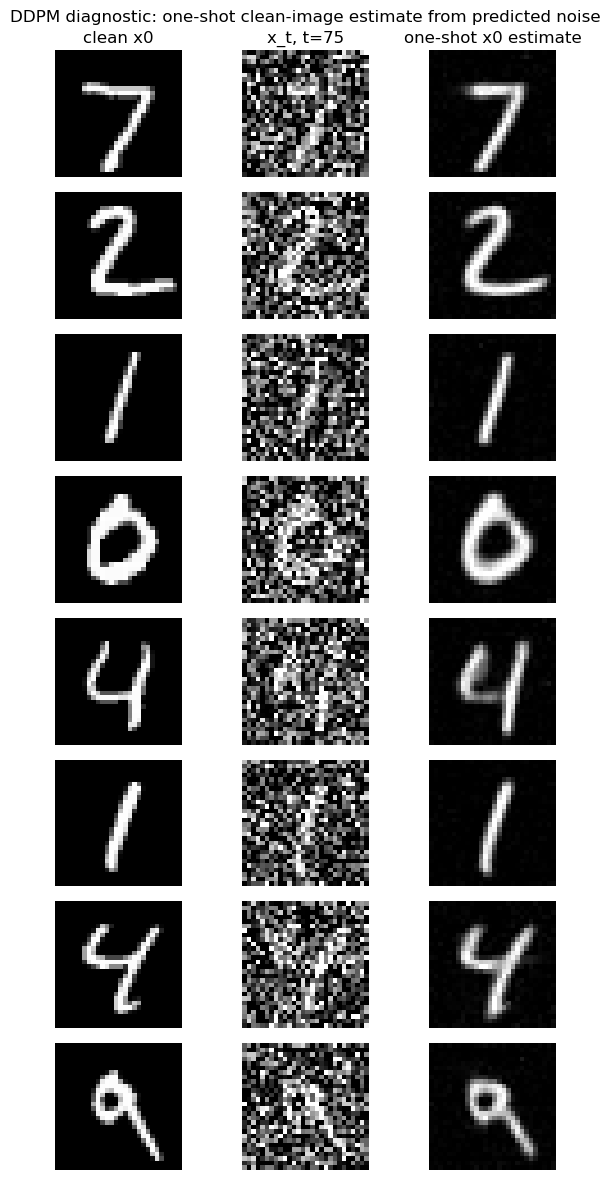

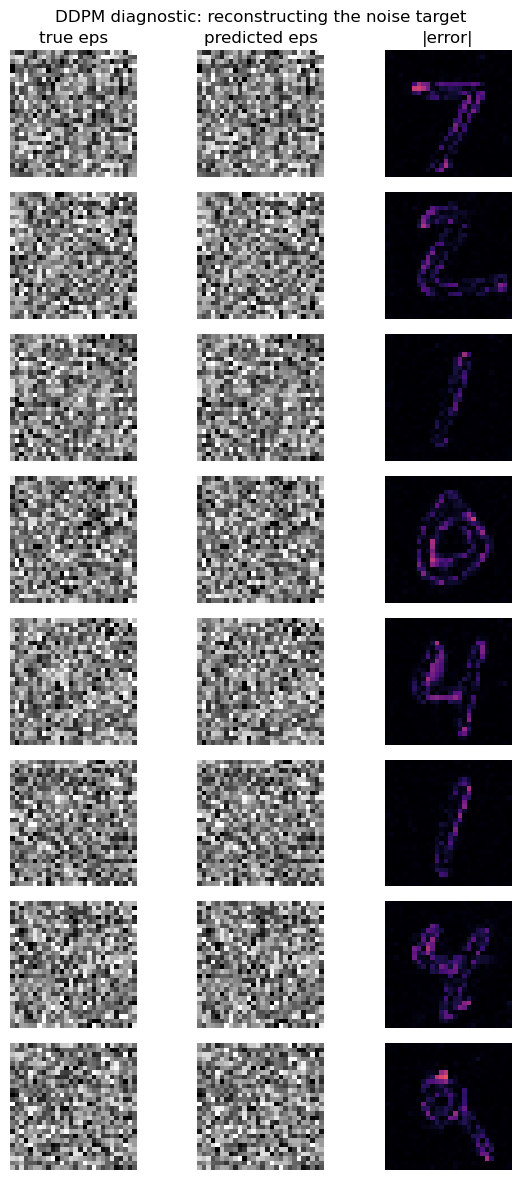


DDPM one-step reverse mean check at t=75: MSE(pred mean, oracle mean)=0.00003


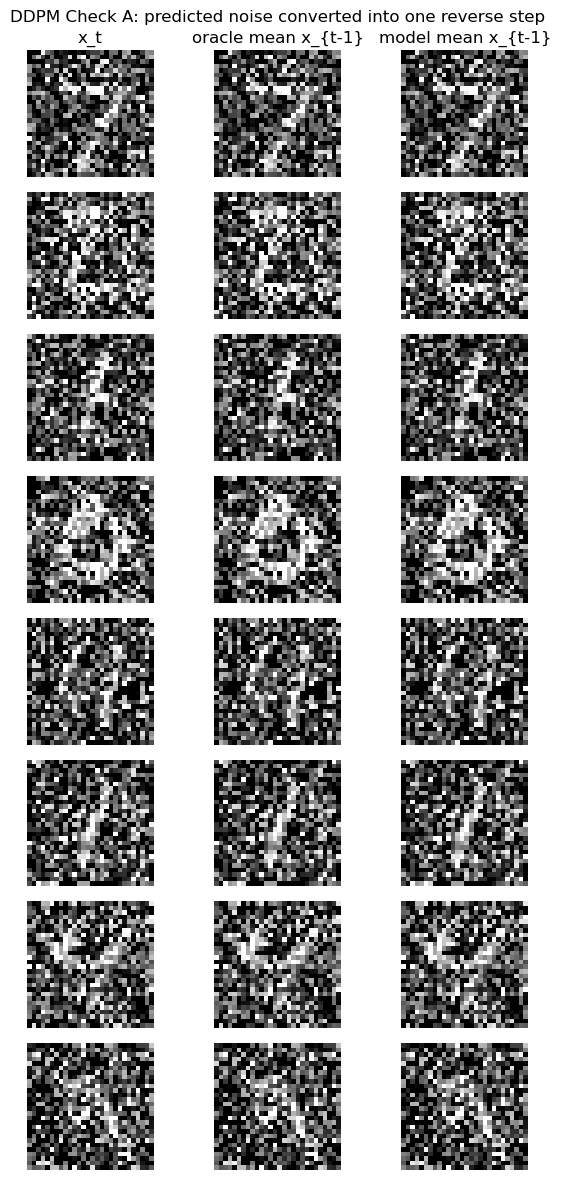

In [50]:
# Train eps_theta
import copy

model = EpsModel().to(device)
ema_model = copy.deepcopy(model).to(device)
for p in ema_model.parameters():
    p.requires_grad_(False)

opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

epochs = 50
max_batches_per_epoch = 200  # cap runtime for lecture demo; set to None for full MNIST each epoch
EMA_DECAY = 0.995

@torch.no_grad()
def update_ema(ema, current, decay=0.995):
    for p_ema, p in zip(ema.parameters(), current.parameters()):
        p_ema.data.mul_(decay).add_(p.data, alpha=1.0 - decay)

print('Training noise predictor...')
for epoch in range(epochs):
    model.train()
    total = 0.0
    n_batches = 0

    for batch_idx, (x0, _) in enumerate(train_dl):
        if max_batches_per_epoch is not None and batch_idx >= max_batches_per_epoch:
            break

        x0 = x0.to(device)
        b = x0.shape[0]

        t = torch.randint(1, T + 1, (b,), device=device, dtype=torch.long)
        eps = torch.randn_like(x0)
        x_t = q_sample(x0, t, eps)

        eps_pred = model(x_t, t)
        loss = F.mse_loss(eps_pred, eps)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        update_ema(ema_model, model, EMA_DECAY)

        total += loss.item()
        n_batches += 1

    sched.step()
    denom = max(1, n_batches)
    if (epoch + 1) in {1, epochs} or (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}  loss={total/denom:.5f}  lr={sched.get_last_lr()[0]:.2e}")

# Diagnostics: can the trained model reconstruct the noise and recover x0 from x_t?
@torch.no_grad()
def ddpm_reconstruction_diagnostics(model_for_eval, x0_batch, t_values=(10, 25, 50, 75, 100)):
    model_for_eval.eval()
    x0_batch = x0_batch.to(device)
    rows = []
    for t_val in t_values:
        t_val = min(int(t_val), T)
        t = torch.full((x0_batch.shape[0],), t_val, device=device, dtype=torch.long)
        eps = torch.randn_like(x0_batch)
        x_t = q_sample(x0_batch, t, eps)
        eps_pred = model_for_eval(x_t, t)
        x0_hat_true_eps = predict_x0_from_eps(x_t, t, eps)
        x0_hat_pred_eps = predict_x0_from_eps(x_t, t, eps_pred).clamp(-1, 1)
        a_bar = float(alpha_bar0[t_val].detach().cpu())
        amp = float(np.sqrt((1.0 - a_bar) / max(a_bar, 1e-12)))
        rows.append({
            't': t_val,
            'alpha_bar': a_bar,
            'eps_error_amplification': amp,
            'noise_mse': F.mse_loss(eps_pred, eps).item(),
            'x0_mse_true_eps': F.mse_loss(x0_hat_true_eps, x0_batch).item(),
            'x0_mse_pred_eps': F.mse_loss(x0_hat_pred_eps, x0_batch).item(),
            'x_t': x_t.detach().cpu(),
            'x0_hat': x0_hat_pred_eps.detach().cpu(),
            'eps': eps.detach().cpu(),
            'eps_pred': eps_pred.detach().cpu(),
        })
    return rows

# Use EMA weights for evaluation/sampling; they are usually cleaner than raw training weights.
diag_rows = ddpm_reconstruction_diagnostics(ema_model, imgs_test[:8], t_values=(10, 25, 50, 75, 100))
print('\nOne-shot reconstruction diagnostics after noise-prediction training:')
for r in diag_rows:
    print(
        f"  t={r['t']:3d}  alpha_bar={r['alpha_bar']:.4f}  amp={r['eps_error_amplification']:.2f}x  "
        f"noise_mse={r['noise_mse']:.4f}  x0_mse(true eps)={r['x0_mse_true_eps']:.2e}  "
        f"x0_mse(pred eps)={r['x0_mse_pred_eps']:.4f}"
    )

# Visualize x_t and x0 reconstructed from predicted noise at a moderate timestep.
mid = diag_rows[3]  # t=75 by default: visibly noisy, but not hopelessly amplified
fig, axes = plt.subplots(8, 3, figsize=(6.2, 12))
for i in range(8):
    axes[i, 0].imshow(to_display(imgs_test[i:i+1])[0, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 1].imshow(to_display(mid['x_t'][i:i+1])[0, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 2].imshow(to_display(mid['x0_hat'][i:i+1])[0, 0], cmap='gray', vmin=0, vmax=1)
    for j in range(3):
        axes[i, j].axis('off')
axes[0, 0].set_title('clean x0')
axes[0, 1].set_title(f"x_t, t={mid['t']}")
axes[0, 2].set_title('one-shot x0 estimate')
plt.suptitle('DDPM diagnostic: one-shot clean-image estimate from predicted noise')
plt.tight_layout(); plt.show()

# Visualize the actual supervised target: true noise vs predicted noise.
fig, axes = plt.subplots(8, 3, figsize=(6.2, 12))
for i in range(8):
    # Noise is not an image, so display with a symmetric range around zero.
    axes[i, 0].imshow(mid['eps'][i, 0], cmap='gray', vmin=-2, vmax=2)
    axes[i, 1].imshow(mid['eps_pred'][i, 0], cmap='gray', vmin=-2, vmax=2)
    axes[i, 2].imshow((mid['eps'][i, 0] - mid['eps_pred'][i, 0]).abs(), cmap='magma', vmin=0, vmax=2)
    for j in range(3):
        axes[i, j].axis('off')
axes[0, 0].set_title('true eps')
axes[0, 1].set_title('predicted eps')
axes[0, 2].set_title('|error|')
plt.suptitle('DDPM diagnostic: reconstructing the noise target')
plt.tight_layout(); plt.show()



# Check A, part 2: one-step reverse mean x_t -> x_{t-1} using predicted noise.
@torch.no_grad()
def ddpm_one_step_reverse_check(model_for_eval, x0_batch, t_val=75):
    model_for_eval.eval()
    x0_batch = x0_batch.to(device)
    t_val = min(int(t_val), T)
    t = torch.full((x0_batch.shape[0],), t_val, device=device, dtype=torch.long)

    eps = torch.randn_like(x0_batch)
    x_t = q_sample(x0_batch, t, eps)
    eps_pred = model_for_eval(x_t, t)

    # Oracle reverse mean: what the DDPM formula would produce if the true aggregate eps were known.
    x_prev_mean_true = reverse_mean_from_eps(x_t, t, eps)

    # Model reverse mean: same formula, but using predicted eps.
    x_prev_mean_pred = reverse_mean_from_eps(x_t, t, eps_pred)

    return {
        't': t_val,
        'x_t': x_t.detach().cpu(),
        'x_prev_mean_true': x_prev_mean_true.detach().cpu(),
        'x_prev_mean_pred': x_prev_mean_pred.detach().cpu(),
        'mean_mse': F.mse_loss(x_prev_mean_pred, x_prev_mean_true).item(),
    }

one_step_eps = ddpm_one_step_reverse_check(ema_model, imgs_test[:8], t_val=75)
print(f"\nDDPM one-step reverse mean check at t={one_step_eps['t']}: "
      f"MSE(pred mean, oracle mean)={one_step_eps['mean_mse']:.5f}")

fig, axes = plt.subplots(8, 3, figsize=(6.2, 12))
for i in range(8):
    axes[i, 0].imshow(to_display(one_step_eps['x_t'][i:i+1])[0, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 1].imshow(to_display(one_step_eps['x_prev_mean_true'][i:i+1])[0, 0], cmap='gray', vmin=0, vmax=1)
    axes[i, 2].imshow(to_display(one_step_eps['x_prev_mean_pred'][i:i+1])[0, 0], cmap='gray', vmin=0, vmax=1)
    for j in range(3):
        axes[i, j].axis('off')
axes[0, 0].set_title('x_t')
axes[0, 1].set_title('oracle mean x_{t-1}')
axes[0, 2].set_title('model mean x_{t-1}')
plt.suptitle('DDPM Check A: predicted noise converted into one reverse step')
plt.tight_layout(); plt.show()


---
### Check B for noise prediction: full DDPM generation rollout

Now we test the real generation loop:

$$x_T \rightarrow x_{T-1} \rightarrow \cdots \rightarrow x_0.$$

At every step, the same model predicts noise from the current image, and the DDPM scheduler converts that prediction into the next reverse state. This is why we do not simply take the first recovered $\hat x_0$ from $x_T$: early $\hat x_0$ estimates are rough, while the reverse chain refines the image gradually.


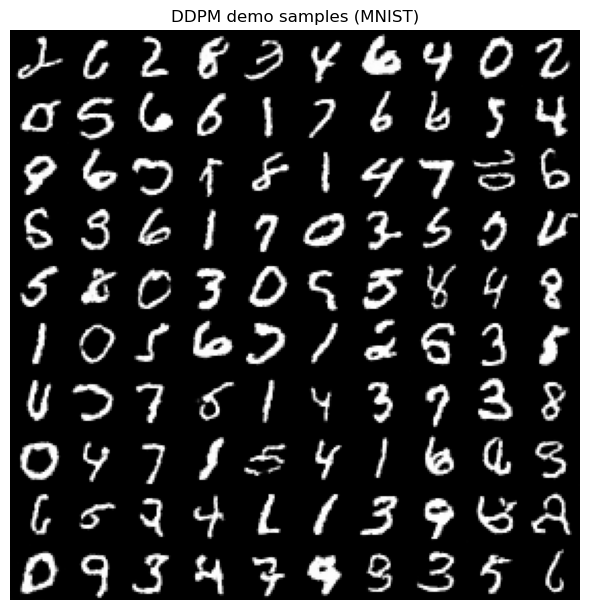

In [51]:
# Generate samples (start from noise -> denoise)

sample_model = ema_model if 'ema_model' in globals() else model
x_gen = sample_ddpm(sample_model, n=100).cpu().numpy()

grid_n = 10
canvas = np.zeros((28*grid_n, 28*grid_n))
k = 0
for i in range(grid_n):
    for j in range(grid_n):
        canvas[i*28:(i+1)*28, j*28:(j+1)*28] = to_display(torch.tensor(x_gen[k:k+1]))[0,0].numpy()
        k += 1

plt.figure(figsize=(6.2, 6.2))
plt.imshow(canvas, cmap='gray')
plt.axis('off')
plt.title('DDPM demo samples (MNIST)')
plt.tight_layout(); plt.show()


---
### Final evaluation structure

Each learned reverse parameterization is now evaluated with the same pattern.

| Method | Check A: local behavior | Check B: full generation |
|---|---|---|
| Predict $x_{t-1}$ | Compare predicted previous noisy state with the true one-step target | Start from $x_T$ and repeatedly predict $x_{t-1}$ |
| Predict $x_0$ | Predict clean image from data-created $x_t$ | Start from $x_T$, repeatedly predict $\hat x_0$, infer noise, and step to $x_{t-1}$ |
| Predict $\varepsilon$ | Predict noise, recover $\hat x_0$, and compute one reverse mean for $x_{t-1}$ | Start from $x_T$ and run the DDPM reverse sampler |

The important lesson is that local correctness is necessary but not sufficient. A method can look reasonable in Check A and still fail in Check B if repeated reverse steps accumulate errors or leave the data distribution.


---
## Takeaway

- The forward diffusion process is a known **Gaussian-kernel Markov chain**: clean data $x_0$ gradually becomes noise $x_T$.
- If we save the true injected noise, backward reconstruction is algebraically exact. The difficulty is that generation starts from fresh noise, where those hidden noise variables are unknown.
- A naive reverse model can directly predict $x_{t-1}$, but long rollouts tend to be blurry or unstable because the target changes with timestep and uncertainty compounds.
- Predicting $x_0$ from $x_t$ is valid and intuitive, but it becomes difficult at large $t$.
- DDPMs often predict the noise $\varepsilon$ because that target has standardized scale/distribution across timesteps; it also lets us estimate $x_0$ and defines a principled stochastic reverse sampler.
- In a tiny classroom model, one-shot high-noise reconstructions may still look imperfect; the diagnostics show why noise error is amplified at large timesteps.
